In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("mymoviedb.csv", lineterminator="\n")

In [4]:
df.head()


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [6]:
df["Genre"].head()

,Genre
0,"Action, Adventure, Science Fiction"
1,"Crime, Mystery, Thriller"
2,Thriller
3,"Animation, Comedy, Family, Fantasy"
4,"Action, Adventure, Thriller, War"


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


In [9]:
df["Release_Date"] = pd.to_datetime(df["Release_Date"]) #covert release date string format to integer
print(df["Release_Date"])

0      2021-12-15
1      2022-03-01
2      2022-02-25
3      2021-11-24
4      2021-12-22
          ...    
9822   1973-10-15
9823   2020-10-01
9824   2016-05-06
9825   2021-03-31
9826   1984-09-23
Name: Release_Date, Length: 9827, dtype: datetime64[ns]


In [10]:
print(df["Release_Date"].dtypes) #cheack format

datetime64[ns]


In [11]:
df["Release_Date"]=df["Release_Date"].dt.year #TO ACCESS ONLY YEAR FROM D/M/Y

In [12]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [13]:
Cols = ["Overview","Original_Language","Poster_Url"] # the columns which we want to remove and meaningless for data analysis
df.drop(Cols, axis=1, inplace=True)  #DROPPING THE COLUMNS


In [14]:
print(df.columns)

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')


In [15]:
df.head() #to check and verify the columns

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


In [16]:
def categorize_col(df, col, labels): #create user defined function which contain df(datset),col(columns),labels
    edges = [df[col].describe()["min"],
             df[col].describe()["25%"],
             df[col].describe()["50%"],
             df[col].describe()["75%"],
             df[col].describe()["max"]]
    df[col] = pd.cut(df[col],edges,labels=labels,duplicates="drop")
    return df
    #Categoring Vote_Average column into 4 categories : popular ,average, bellow_average, not_popular using categorize_col() function



In [17]:
labels = ["not_popular", "bellow_avg", "avg", "popular"]
categorize_col(df, "Vote_Average", labels)
df["Vote_Average"].unique()

['popular', 'bellow_avg', 'avg', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'bellow_avg' < 'avg' < 'popular']

In [18]:
df["Vote_Average"]

,Vote_Average
0,popular
1,popular
2,bellow_avg
3,popular
4,avg
...,...
9822,popular
9823,not_popular
9824,not_popular
9825,avg


In [ ]:
df.head() #to verify labels in columns

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,bellow_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,avg,"Action, Adventure, Thriller, War"


In [19]:
df["Vote_Average"].value_counts()

,count
Vote_Average,
not_popular,2467
popular,2450
avg,2412
bellow_avg,2398


In [20]:
df.isna().sum() # to check our data contain missing values or not

,0
Release_Date,0
Title,0
Popularity,0
Vote_Count,0
Vote_Average,100
Genre,0


In [21]:
df.dropna(inplace = True) # dropna used to remove and implace = true means permanently
df.isna().sum() # to verify it is removed

,0
Release_Date,0
Title,0
Popularity,0
Vote_Count,0
Vote_Average,0
Genre,0


In [22]:
df["Genre"]=df["Genre"].str.split(', ') #we split genure into list then explore dataframe to have only one genure per row for each movie
df = df.explode("Genre").reset_index(drop=True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [23]:
df["Genre"] = df["Genre"].astype("category") #for show all categories in genre
df["Genre"].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [24]:
df.info() #to show table in data 25552

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25552 non-null  int32   
 1   Title         25552 non-null  object  
 2   Popularity    25552 non-null  float64 
 3   Vote_Count    25552 non-null  int64   
 4   Vote_Average  25552 non-null  category
 5   Genre         25552 non-null  category
dtypes: category(2), float64(1), int32(1), int64(1), object(1)
memory usage: 749.6+ KB


In [25]:
df.nunique()

,0
Release_Date,100
Title,9415
Popularity,8088
Vote_Count,3265
Vote_Average,4
Genre,19


In [26]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


## ***now preprocessing complete lets do visualization :***

In [27]:
sns.set_style("whitegrid")

### ***What is most frequent Genre of movies Netflix released ?***

In [28]:
df["Genre"].describe()

,Genre
count,25552
unique,19
top,Drama
freq,3715


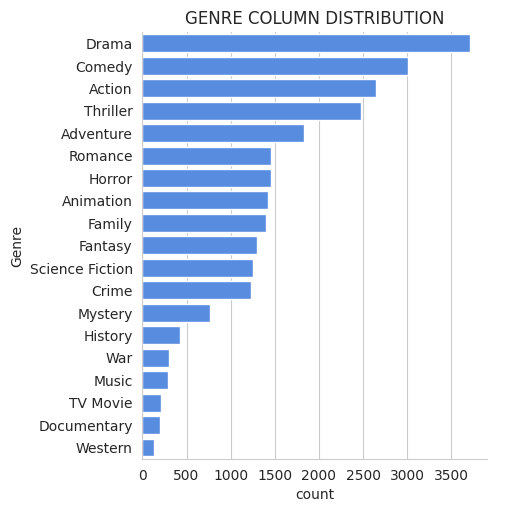

In [29]:
sns.catplot(y="Genre",data = df,kind = "count",
            order =df["Genre"].value_counts().index,
            color = "#4287f5")
plt.title("GENRE COLUMN DISTRIBUTION")
plt.show()

### **WHAT HAS THE HIGHEST VOTE IN VOTE AVG COLUMNS ?**



In [30]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


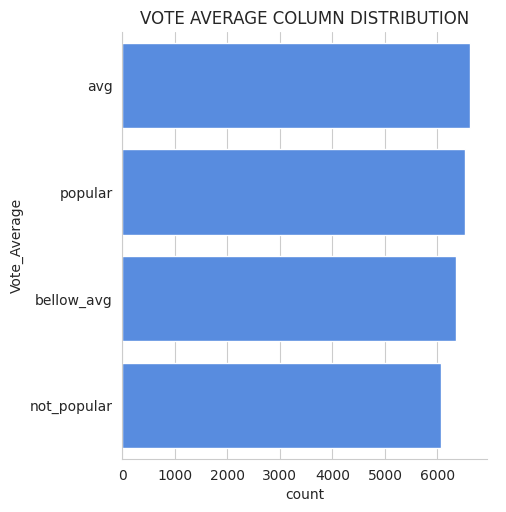

In [31]:
sns.catplot(y="Vote_Average",data = df,kind = "count",
            order =df["Vote_Average"].value_counts().index,
            color = "#4287F5")
plt.title("VOTE AVERAGE COLUMN DISTRIBUTION")
plt.show()

# ***WHAT MOVIE GOT THE HIGHEST POPULARITY ? WHAT IS ITS GENRE ?***

In [32]:
df[df["Popularity"] == df["Popularity"].max()]


,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction


## **WHAT MOVIE GOT THE lowest POPULARITY ? WHAT IS ITS GENRE ?**

In [33]:
df[df["Popularity"] == df["Popularity"].min()]


,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25546,2021,The United States vs. Billie Holiday,13.354,152,avg,Music
25547,2021,The United States vs. Billie Holiday,13.354,152,avg,Drama
25548,2021,The United States vs. Billie Holiday,13.354,152,avg,History
25549,1984,Threads,13.354,186,popular,War
25550,1984,Threads,13.354,186,popular,Drama
25551,1984,Threads,13.354,186,popular,Science Fiction


# **which year has the most fillmed movie ?

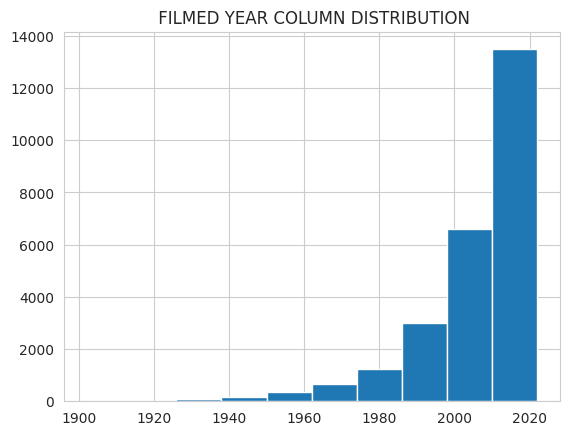

In [34]:
df["Release_Date"].hist()
plt.title(" FILMED YEAR COLUMN DISTRIBUTION")
plt.show()

Q. What are the findings from the Exploratory Data Analysis (EDA)?

Answer:

We have a dataframe consisting of 9827 rows and 9 columns.
Our dataset looks a bit tidy with no missing values (NaNs) and no duplicate values.
The Release_Date column needs to be converted into datetime format and only the year should be extracted.
The Overview, Original_Language, and Poster_Url columns are not useful for analysis, so they can be dropped.
There are noticeable outliers in the Popularity column.
The Vote_Average column should be categorized into groups for better analysis.
The Genre column contains comma-separated values and extra white spaces that need to be cleaned and converted into categorical format.
Short Answer for Notebook/Exam

Exploration Summary

Dataset contains 9827 rows and 9 columns.
No missing values and no duplicate records.
Convert Release_Date to datetime format.
Remove Overview, Original_Language, and Poster_Url columns.
Popularity contains outliers.
Categorize Vote_Average into meaningful groups.
# Clean and process the Genre column for analysis.**bold text**